In [22]:
import numpy as np
import matplotlib.pyplot as plt

# time axis
t = np.linspace(0, 10, 200)

# Signal 1: sine wave
signal1 = np.sin(2 * np.pi * 0.5 * t)

# Signal 2: square wave (derived from sine)
signal2 = np.sign(np.sin(2 * np.pi * 0.5 * t))

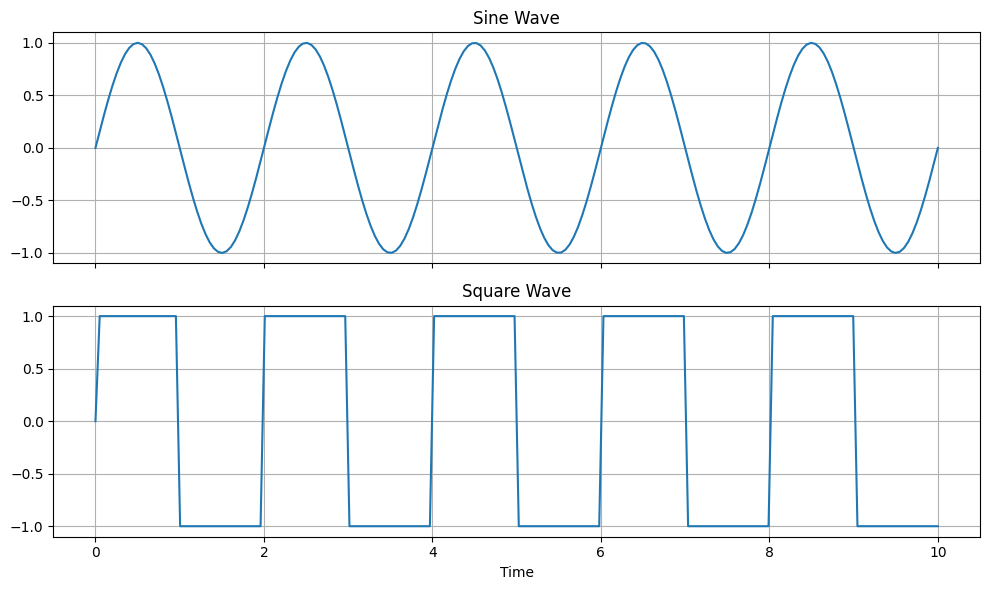

In [23]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Sine wave
axs[0].plot(t, signal1)
axs[0].set_title("Sine Wave")
axs[0].grid(True)

# Square wave
axs[1].plot(t, signal2)
axs[1].set_title("Square Wave")
axs[1].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

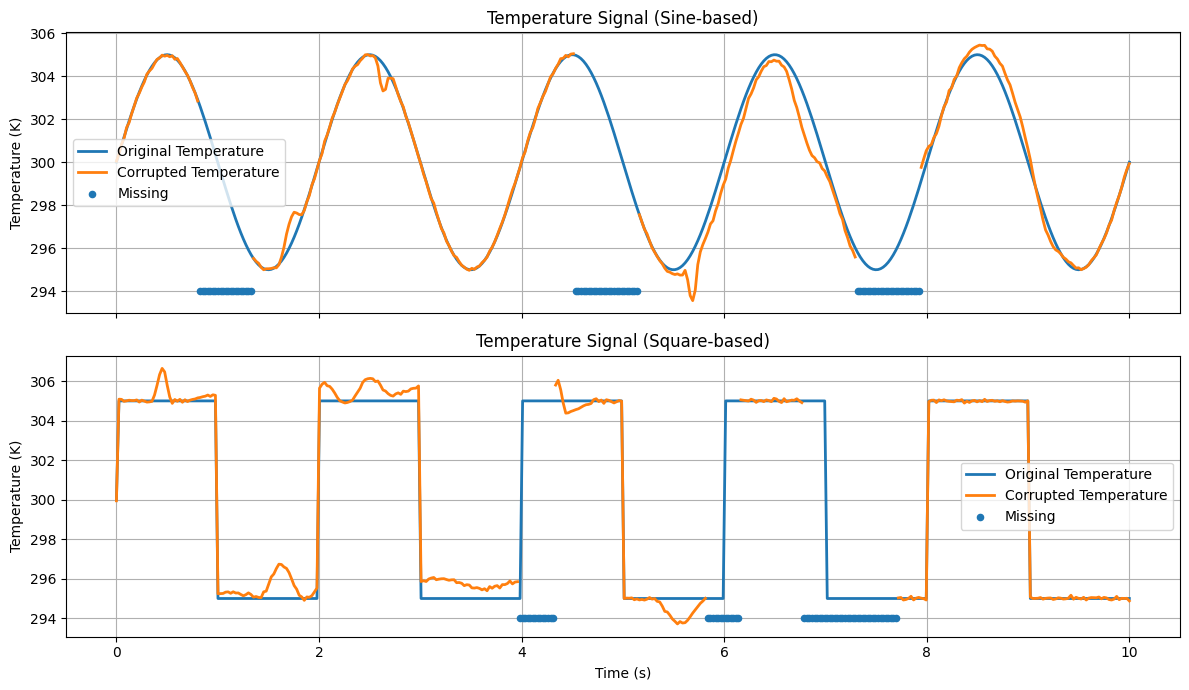

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# base signals
# -----------------------------
t = np.linspace(0, 10, 400)
signal1 = np.sin(2 * np.pi * 0.5 * t)
signal2 = np.sign(np.sin(2 * np.pi * 0.5 * t))

# convert to temperature scale
# -----------------------------
T_base = 300      # baseline temperature (Kelvin)
T_amp = 5         # variation amplitude

signal1_temp = T_base + T_amp * signal1
signal2_temp = T_base + T_amp * signal2
# -----------------------------
# corruption function
# -----------------------------
def corrupt_signal(
    signal,
    n_shift_segments=5,
    shift_min_len=20,
    shift_max_len=60,
    min_shift=0.3,
    max_shift=1.0,
    n_missing_segments=4,
    missing_min_len=8,
    missing_max_len=25,
    n_spikes=6,
    spike_min_amp=0.8,
    spike_max_amp=2.0,
    jitter_std=0.05,
):
    corrupted = signal.copy()
    N = len(signal)

    # 1) segment-wise upward/downward shifts
    for _ in range(n_shift_segments):
        seg_len = np.random.randint(shift_min_len, shift_max_len + 1)
        start = np.random.randint(0, N - seg_len)
        end = start + seg_len

        shift = np.random.uniform(min_shift, max_shift)
        if np.random.rand() < 0.5:
            shift = -shift

        window = np.hanning(seg_len)   # smooth entry/exit
        corrupted[start:end] += shift * window

    # 2) unusual peaks and troughs
    for _ in range(n_spikes):
        center = np.random.randint(0, N)
        width = np.random.randint(3, 12)

        amp = np.random.uniform(spike_min_amp, spike_max_amp)
        if np.random.rand() < 0.5:
            amp = -amp   # negative gives trough/dip

        left = max(0, center - width)
        right = min(N, center + width + 1)
        pulse_len = right - left

        pulse = np.hanning(pulse_len)
        corrupted[left:right] += amp * pulse

    # 3) small random jitter everywhere
    corrupted += np.random.normal(0, jitter_std, N)

    # 4) missing segments
    missing_mask = np.zeros(N, dtype=bool)
    for _ in range(n_missing_segments):
        seg_len = np.random.randint(missing_min_len, missing_max_len + 1)
        start = np.random.randint(0, N - seg_len)
        end = start + seg_len
        missing_mask[start:end] = True

    corrupted[missing_mask] = np.nan

    return corrupted, missing_mask


# -----------------------------
# create corrupted versions
# -----------------------------

signal1_corrupted, mask1 = corrupt_signal(signal1_temp)
signal2_corrupted, mask2 = corrupt_signal(signal2_temp)


# -----------------------------
# plot
# -----------------------------


# signal 1
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# ---- Signal 1 ----
axs[0].plot(t, signal1_temp, label="Original Temperature", linewidth=2)
axs[0].plot(t, signal1_corrupted, label="Corrupted Temperature", linewidth=2)

# place missing markers slightly below baseline for visibility
missing_y1 = np.full(np.sum(mask1), signal1_temp.min() - 1)
axs[0].scatter(t[mask1], missing_y1, s=20, label="Missing", zorder=3)

axs[0].set_title("Temperature Signal (Sine-based)")
axs[0].set_ylabel("Temperature (K)")
axs[0].grid(True)
axs[0].legend()

# ---- Signal 2 ----
axs[1].plot(t, signal2_temp, label="Original Temperature", linewidth=2)
axs[1].plot(t, signal2_corrupted, label="Corrupted Temperature", linewidth=2)

missing_y2 = np.full(np.sum(mask2), signal2_temp.min() - 1)
axs[1].scatter(t[mask2], missing_y2, s=20, label="Missing", zorder=3)

axs[1].set_title("Temperature Signal (Square-based)")
axs[1].set_ylabel("Temperature (K)")
axs[1].grid(True)
axs[1].legend()

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import pandas as pd

# -----------------------------
# Resampling
# -----------------------------
t_new = np.linspace(0, 10, 101)

signal1_resampled = np.interp(t_new, t, signal1_temp)
signal2_resampled = np.interp(t_new, t, signal2_temp)

# -----------------------------
# Handle corrupted signals
# -----------------------------
valid1 = ~np.isnan(signal1_corrupted)
valid2 = ~np.isnan(signal2_corrupted)

signal1_corr_resampled = np.interp(t_new, t[valid1], signal1_corrupted[valid1])
signal2_corr_resampled = np.interp(t_new, t[valid2], signal2_corrupted[valid2])

# restore missing regions
mask1_new = np.interp(t_new, t, valid1.astype(float)) < 0.5
mask2_new = np.interp(t_new, t, valid2.astype(float)) < 0.5

signal1_corr_resampled[mask1_new] = np.nan
signal2_corr_resampled[mask2_new] = np.nan

# -----------------------------
# Create DataFrame
# -----------------------------
df_new = pd.DataFrame({
    "time": t_new,
    "signal1_clean": signal1_resampled,
    "signal1_corrupted": signal1_corr_resampled,
    "signal2_clean": signal2_resampled,
    "signal2_corrupted": signal2_corr_resampled
})

# =============================
# 🔥 ADD OUTLIER REMOVAL HERE
# =============================


# -----------------------------
# helper: local outlier -> NaN
# -----------------------------
def local_outlier_mask(signal, window=5, threshold=3):
    signal = signal.copy()

    for i in range(len(signal)):
        left = max(0, i - window)
        right = min(len(signal), i + window + 1)

        local = signal[left:right]
        local_mean = np.nanmean(local)
        local_std = np.nanstd(local)

        if not np.isnan(signal[i]) and local_std > 0:
            if abs(signal[i] - local_mean) > threshold * local_std:
                signal[i] = np.nan

    return signal


# -----------------------------
# helper: make one sequence
# -----------------------------
def make_one_sequence():
    # high-resolution original time
    t = np.linspace(0, 10, 400)

    # clean base signals
    signal1 = np.sin(2 * np.pi * 0.5 * t)
    signal2 = np.sign(np.sin(2 * np.pi * 0.5 * t))

    # convert to temperature
    T_base = 300
    T_amp = 5
    signal1_temp = T_base + T_amp * signal1
    signal2_temp = T_base + T_amp * signal2

    # corrupt them
    signal1_corrupted, _ = corrupt_signal(signal1_temp)
    signal2_corrupted, _ = corrupt_signal(signal2_temp)

    # resample to 101 points
    t_new = np.linspace(0, 10, 101)

    signal1_resampled = np.interp(t_new, t, signal1_temp)
    signal2_resampled = np.interp(t_new, t, signal2_temp)

    valid1 = ~np.isnan(signal1_corrupted)
    valid2 = ~np.isnan(signal2_corrupted)

    signal1_corr_resampled = np.interp(t_new, t[valid1], signal1_corrupted[valid1])
    signal2_corr_resampled = np.interp(t_new, t[valid2], signal2_corrupted[valid2])

    mask1_new = np.interp(t_new, t, valid1.astype(float)) < 0.5
    mask2_new = np.interp(t_new, t, valid2.astype(float)) < 0.5

    signal1_corr_resampled[mask1_new] = np.nan
    signal2_corr_resampled[mask2_new] = np.nan

    # convert distorted values to NaN
    signal1_corr_resampled = local_outlier_mask(signal1_corr_resampled, window=5, threshold=3)
    signal2_corr_resampled = local_outlier_mask(signal2_corr_resampled, window=5, threshold=3)

    # shape: (101, 2)
    X_sample = np.stack([signal1_corr_resampled, signal2_corr_resampled], axis=1)

    # optional clean reference
    Y_sample = np.stack([signal1_resampled, signal2_resampled], axis=1)

    return t_new, X_sample, Y_sample

In [26]:
n_samples = 50

X_all = []
Y_all = []

for _ in range(n_samples):
    t_new, X_sample, Y_sample = make_one_sequence()
    X_all.append(X_sample)
    Y_all.append(Y_sample)

X_all = np.array(X_all)   # shape: (50, 101, 2)
Y_all = np.array(Y_all)   # shape: (50, 101, 2)

print("X_all shape:", X_all.shape)
print("Y_all shape:", Y_all.shape)
print("Total missing values:", np.isnan(X_all).sum())

/tmp/ipykernel_111916/1536014101.py:55: RuntimeWarning: Mean of empty slice
  local_mean = np.nanmean(local)
/home/ashish/temp_seq_nn/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


X_all shape: (50, 101, 2)
Y_all shape: (50, 101, 2)
Total missing values: 1556


In [27]:
import pandas as pd
import numpy as np

rows = []

# loop over sequences
for seq_id in range(X_all.shape[0]):

    # loop over time points
    for t_idx in range(X_all.shape[1]):

        rows.append({
            "sequence_id": seq_id,
            "time_index": t_idx,

            "signal1_corrupted": X_all[seq_id, t_idx, 0],
            "signal2_corrupted": X_all[seq_id, t_idx, 1],

            "signal1_clean": Y_all[seq_id, t_idx, 0],
            "signal2_clean": Y_all[seq_id, t_idx, 1],
        })

# create dataframe
df_all = pd.DataFrame(rows)

# save CSV
df_all.to_csv("all_sequences.csv", index=False)

print("Saved successfully")
print(df_all.head())
print("Total rows:", len(df_all))

Saved successfully
   sequence_id  time_index  signal1_corrupted  signal2_corrupted  \
0            0           0         299.991337         299.951043   
1            0           1         301.463384         305.087028   
2            0           2         302.873369         304.990091   
3            0           3         304.117715         304.988511   
4            0           4         304.781634         304.955179   

   signal1_clean  signal2_clean  
0     300.000000          300.0  
1     301.545041          305.0  
2     302.938754          305.0  
3     304.044727          305.0  
4     304.754721          305.0  
Total rows: 5050
